In [1]:
# Load a random sample of speeches pronounced in the floor of the US Congress between 1994 and 2024
import pandas as pd
df = pd.read_csv('../data/us_congress_speeches_sample.csv')
df['year'] = pd.to_datetime(df['date']).dt.year

print("Number of speeches: {}".format(len(df)))
df.head()

Number of speeches: 28731


,date,text,speaker_bioguide,chamber,party,doc_clean,year
0,2003-06-10,"Mr. ISRAEL. Mr. Speaker, I rise today to com...",I000057,House,Democrat,commend induction successful wrestling coach h...,2003
1,2012-05-08,"Mr. LANGEVIN. Mr. Speaker, Democrats are com...",L000559,House,Democrat,commit reduce deficit balanced way contrast br...,2012
2,2010-03-25,"Mr. BISHOP of Utah. Mr. Speaker, Lori Garver...",B001250,House,Republican,number administrator political give credit pri...,2010
3,1995-01-25,"Mr. KIM. Mr. Chairman, I rise today in suppo...",K000181,House,Republican,balanced budget small business tough run small...,1995
4,2003-05-22,"Mr. BAUCUS. Mr. President, sometime in the n...",B000243,Senate,Democrat,near future eye beholder go conference tax cut...,2003


In [2]:
# Build GTMCorpus()

from deeplatent import Corpus

from sklearn.feature_extraction.text import CountVectorizer

# 1. Define and fit the vectorizer using training data 
vectorizer = CountVectorizer(
    ngram_range=(1, 1),
    max_df=0.95,
    min_df=0.001,
    stop_words="english",
    token_pattern=r"(?u)\b\w{3,}\b"  # only words with 3 or more letters
)

vectorizer.fit(df["doc_clean"])  

print("Number of words in the vocabulary: {}".format(len(vectorizer.get_feature_names_out())))

# 2. Define modalities using the external vectorizer 
modalities = {
    "text": {
        "column": "doc_clean",
        "views": {
            "bow": {
                "type": "bow",
                "vectorizer": vectorizer
            }
        }
    }
}

# 3. Create GTMCorpus with prevalence and content covariates
# Setting to None simply trains a Wasserstein topic model (without metadata).
train_dataset = Corpus(
    df=df,
    modalities=modalities,
    prevalence="~ C(party) + C(chamber) + C(year)",
    content="~ C(party) + C(chamber) + C(year)"
)

Number of words in the vocabulary: 6038


In [3]:
# Train the model
# With initialization = True, the model first learns topics keeping the prior fixed for several epochs, and then updates the prior.
# Initialization may take a few minutes (the model stops the initialization routine as soon as the training loss stops improving).

from deeplatent import GTM

encoder_args = {
    "text_bow": {
        "hidden_dims": [256,128],
        "activation": "relu",
        "bias": True,
        "dropout": 0.1
    }
}

decoder_args = {
    "text_bow": {
        "hidden_dims": [128,256],
        "activation": "relu",
        "bias": True,
        "dropout": 0.1
    }
}

tm = GTM(
    train_dataset, 
    n_topics=20,
    ae_type="wae", # WAE has very stable training and can use a Dirichlet prior, VAE has stronger theoretical guarantees but is prone to posterior collapse
    doc_topic_prior="logistic_normal",
    update_prior=True,
    encoder_args=encoder_args,
    decoder_args=decoder_args,
    batch_size=64,
    w_prior=1,
    return_best_model=True,
    num_steps=10000,
    print_every_n_steps=1000,
    print_topics=True, 
    print_covariates=True
)

# Resume training if you think the topics need more refining
# tm.num_steps = tm.steps + 5000  # Train 5000 more steps
# tm.train(train_data)

Step   1000	Mean Training Loss:7.6080565
Rec Loss:7.4538593
Divergence Loss:0.1541974
Pred Loss:0.0000000

Topic_0: ['program', 'health', 'provide', 'child', 'care']
Topic_1: ['community', 'program', 'child', 'provide', 'school']
Topic_2: ['provide', 'legislation', 'program', 'use', 'health']
Topic_3: ['tax', 'budget', 'cut', 'pay', 'money']
Topic_4: ['know', 'come', 'majority', 'let', 'way']
Topic_5: ['law', 'legislation', 'use', 'require', 'provide']
Topic_6: ['know', 'law', 'come', 'american', 'legislation']
Topic_7: ['tax', 'cut', 'budget', 'pay', 'debt']
Topic_8: ['law', 'weapon', 'right', 'protect', 'use']
Topic_9: ['honor', 'community', 'service', 'life', 'team']
Topic_10: ['leader', 'follow', 'majority', 'hour', 'senator']
Topic_11: ['right', 'law', 'know', 'american', 'come']
Topic_12: ['child', 'school', 'education', 'family', 'program']
Topic_13: ['life', 'woman', 'country', 'man', 'honor']
Topic_14: ['community', 'service', 'honor', 'life', 'school']
Topic_15: ['know', 'com

In [4]:
print(
    "\n".join(
        [
            "{}: {}".format(str(k), str(v))
            for k, v in tm.get_topic_words(topK=5).items()
        ]
    )
)

Topic_0: ['cancer', 'health', 'care', 'woman', 'research']
Topic_1: ['research', 'program', 'water', 'provide', 'new']
Topic_2: ['financial', 'require', 'legislation', 'provide', 'provision']
Topic_3: ['budget', 'spending', 'cut', 'debt', 'deficit']
Topic_4: ['majority', 'pass', 'come', 'know', 'way']
Topic_5: ['water', 'land', 'waste', 'area', 'legislation']
Topic_6: ['trade', 'country', 'agreement', 'american', 'market']
Topic_7: ['tax', 'cut', 'pay', 'family', 'taxis']
Topic_8: ['gun', 'weapon', 'drug', 'law', 'use']
Topic_9: ['team', 'win', 'game', 'season', 'championship']
Topic_10: ['follow', 'hour', 'business', 'leader', 'divide']
Topic_11: ['law', 'court', 'case', 'section', 'action']
Topic_12: ['school', 'education', 'child', 'program', 'student']
Topic_13: ['honor', 'nation', 'war', 'man', 'country']
Topic_14: ['student', 'school', 'education', 'teacher', 'community']
Topic_15: ['right', 'country', 'woman', 'law', 'american']
Topic_16: ['life', 'family', 'love', 'know', 'chil

In [5]:
print(
    "\n".join(
        [
            "{}: {}".format(str(k), str(v))
            for k, v in tm.get_covariate_words(topK=5).items()
        ]
    )
)

Intercept: ['program', 'country', 'legislation', 'community', 'provide']
C(party)[T.Independent]: ['program', 'country', 'know', 'job', 'legislation']
C(party)[T.Libertarian]: ['security', 'intelligence', 'law', 'information', 'legislation']
C(party)[T.Popular Democrat]: ['program', 'provide', 'law', 'include', 'use']
C(party)[T.Republican]: ['program', 'country', 'provide', 'new', 'legislation']
C(chamber)[T.Senate]: ['program', 'legislation', 'provide', 'country', 'know']
C(year)[T.1995]: ['program', 'legislation', 'country', 'provide', 'cost']
C(year)[T.1996]: ['program', 'legislation', 'country', 'provide', 'know']
C(year)[T.1997]: ['program', 'provide', 'country', 'nation', 'family']
C(year)[T.1998]: ['legislation', 'program', 'country', 'problem', 'state']
C(year)[T.1999]: ['program', 'legislation', 'provide', 'country', 'government']
C(year)[T.2000]: ['drug', 'country', 'provide', 'legislation', 'program']
C(year)[T.2001]: ['country', 'know', 'come', 'nation', 'program']
C(year)

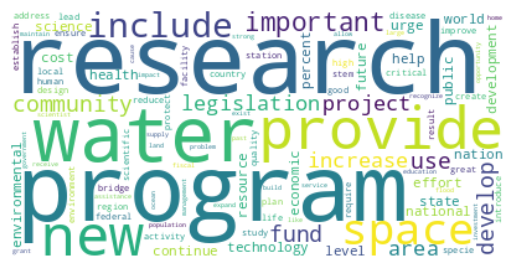

In [6]:
tm.plot_topic_word_distribution(topic_id=1, plot_type='wordcloud')

In [7]:
# Effect of covariates on topic slant (content)
print("Top words per topic for a Democrat speaker:")
print(pd.DataFrame(tm.get_topic_words(l_content_covariates = ["Intercept"], topK=5)).T)

print("\nTop words per topic for a Republican speaker:")
print(pd.DataFrame(tm.get_topic_words(l_content_covariates = ["Intercept", "C(party)[T.Republican]"], topK=5)).T)

Top words per topic for a Democrat speaker:
                  0         1          2          3             4
Topic_0      cancer    health       care      woman        breast
Topic_1    research   program      water      space           new
Topic_2   financial      bank    require    provide   legislation
Topic_3      budget       cut   spending    deficit          debt
Topic_4    majority      pass       come        way          know
Topic_5       water      land      waste       area   legislation
Topic_6       trade   country   american     worker     agreement
Topic_7         tax       cut        pay     family        income
Topic_8         gun      drug     weapon        law         crime
Topic_9        team       win       game     season  championship
Topic_10     follow      hour   business     leader         offer
Topic_11      court      case        law      state        action
Topic_12     school     child  education    program       student
Topic_13      honor    nation   